# 09 – Car Parts Wheel-Fixed Baseline Training

> **Work in Progress (WIP):** The wheel-fixed baseline has been trained and validated, but missing-wheel annotation candidates are still under review. Hyperparameter tuning has not started.

## Purpose

This notebook trains and evaluates a YOLO11n segmentation baseline using the final wheel-corrected dataset, preserves the current validation evidence, and documents the remaining annotation-audit work before hyperparameter tuning.

## 1. Setup

In [3]:
%pip install -q ultralytics==8.4.138

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 4.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
from pathlib import Path

import pandas as pd
import yaml
import torch
import matplotlib.pyplot as plt

from PIL import Image
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [5]:
print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
GPU available: True
GPU: Tesla T4


## 2. Configuration and Paths

In [6]:
DATASET_INPUT_DIR = Path(
    "/kaggle/input/datasets/haifafd/car-parts-wheel-fixed-v3"
)

SOURCE_YAML = next(
    DATASET_INPUT_DIR.rglob("corrected-carparts.yaml")
)

DATASET_DIR = SOURCE_YAML.parent
DATASET_YAML = Path("/kaggle/working/corrected-carparts.yaml")
RUNS_DIR = Path("/kaggle/working/qaddir-training-results")

RUNS_DIR.mkdir(parents=True, exist_ok=True)

## 3. Data Loading

In [7]:
with open(SOURCE_YAML) as file:
    data_config = yaml.safe_load(file)

data_config["path"] = str(DATASET_DIR)
data_config["train"] = "images/train"
data_config["val"] = "images/val"
data_config["test"] = "images/test"

with open(DATASET_YAML, "w") as file:
    yaml.safe_dump(
        data_config,
        file,
        sort_keys=False
    )

In [8]:
settings_df = pd.DataFrame({
    "Setting": [
        "Dataset",
        "Training YAML",
        "Results directory",
        "Number of classes"
    ],
    "Value": [
        str(DATASET_DIR),
        str(DATASET_YAML),
        str(RUNS_DIR),
        len(data_config["names"])
    ]
})

display(settings_df)

,Setting,Value
0,Dataset,/kaggle/input/datasets/haifafd/car-parts-wheel...
1,Training YAML,/kaggle/working/corrected-carparts.yaml
2,Results directory,/kaggle/working/qaddir-training-results
3,Number of classes,13


## 4. Data Validation

In [9]:
image_extensions = {".jpg", ".jpeg", ".png"}

split_summary = []

for split in ["train", "val", "test"]:
    images_dir = DATASET_DIR / "images" / split
    labels_dir = DATASET_DIR / "labels" / split

    image_files = [
        path for path in images_dir.iterdir()
        if path.suffix.lower() in image_extensions
    ]

    label_files = list(labels_dir.glob("*.txt"))

    image_stems = {path.stem for path in image_files}
    label_stems = {path.stem for path in label_files}

    polygons = 0
    wheel_polygons = 0
    empty_labels = 0

    for label_path in label_files:
        lines = [
            line for line in label_path.read_text().splitlines()
            if line.strip()
        ]

        polygons += len(lines)
        wheel_polygons += sum(
            int(line.split()[0]) == 12
            for line in lines
        )

        if not lines:
            empty_labels += 1

    split_summary.append({
        "Split": split,
        "Images": len(image_files),
        "Labels": len(label_files),
        "Polygons": polygons,
        "Wheel Polygons": wheel_polygons,
        "Missing Labels": len(image_stems - label_stems),
        "Missing Images": len(label_stems - image_stems),
        "Empty Labels": empty_labels
    })

split_summary_df = pd.DataFrame(split_summary)
display(split_summary_df)

,Split,Images,Labels,Polygons,Wheel Polygons,Missing Labels,Missing Images,Empty Labels
0,train,3269,3269,20893,2005,0,0,0
1,val,561,561,3143,188,0,0,0
2,test,554,554,3019,176,0,0,0


## 5. Analysis and Visualization

In [12]:
names = data_config["names"]

if isinstance(names, list):
    class_names = {
        class_id: class_name
        for class_id, class_name in enumerate(names)
    }
else:
    class_names = {
        int(class_id): class_name
        for class_id, class_name in names.items()
    }

class_counts = {
    class_id: 0
    for class_id in class_names
}

for label_path in (DATASET_DIR / "labels" / "train").glob("*.txt"):
    for line in label_path.read_text().splitlines():
        if line.strip():
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

class_distribution_df = pd.DataFrame({
    "Class": [
        class_names[class_id]
        for class_id in class_counts
    ],
    "Train Instances": [
        class_counts[class_id]
        for class_id in class_counts
    ]
})

display(class_distribution_df)

,Class,Train Instances
0,back_bumper,935
1,back_door,1752
2,back_glass,939
3,back_light,2202
4,front_bumper,1884
5,front_door,1973
6,front_glass,1904
7,front_light,3465
8,hood,1971
9,side_mirror,1372


## 6. Processing

In [13]:
training_settings = {
    "model": "yolo11n-seg.pt",
    "epochs": 50,
    "patience": 10,
    "image_size": 640,
    "batch_size": 8,
    "seed": 42
}

display(
    pd.DataFrame(
        training_settings.items(),
        columns=["Setting", "Value"]
    )
)

,Setting,Value
0,model,yolo11n-seg.pt
1,epochs,50
2,patience,10
3,image_size,640
4,batch_size,8
5,seed,42


In [14]:
model = YOLO("yolo11n-seg.pt")

training_results = model.train(
    data=str(DATASET_YAML),

    epochs=50,
    patience=10,
    imgsz=640,
    batch=8,
    device=0,
    workers=2,
    seed=42,
    deterministic=True,

    hsv_h=0.01,
    hsv_s=0.30,
    hsv_v=0.30,
    degrees=10.0,
    translate=0.05,
    scale=0.15,
    shear=0.0,
    perspective=0.0,

    fliplr=0.5,
    flipud=0.0,
    mosaic=0.20,
    close_mosaic=10,
    mixup=0.0,
    cutmix=0.0,
    copy_paste=0.0,

    project=str(RUNS_DIR),
    name="carparts_yolo11n_wheel_fixed_v3",

    save=True,
    save_period=5,
    plots=True
)

In [16]:
from shutil import copy2
from IPython.display import FileLink, display

TRAINING_DIR = Path(
    "/kaggle/working/qaddir-training-results/"
    "carparts_yolo11n_wheel_fixed_v3"
)

BEST_MODEL_PATH = TRAINING_DIR / "weights" / "best.pt"
DOWNLOAD_MODEL_PATH = Path(
    "/kaggle/working/carparts_yolo11n_wheel_fixed_v3_best.pt"
)

copy2(BEST_MODEL_PATH, DOWNLOAD_MODEL_PATH)

print("Best model exists:", DOWNLOAD_MODEL_PATH.exists())
print("Size MB:", round(DOWNLOAD_MODEL_PATH.stat().st_size / 1_000_000, 1))

display(FileLink(str(DOWNLOAD_MODEL_PATH)))

Best model exists: True
Size MB: 6.0


/kaggle/working/carparts_yolo11n_wheel_fixed_v3_best.pt

## 7. Results

### 7.1 Validation Results

In [17]:
BEST_MODEL_PATH = Path(
    "/kaggle/working/qaddir-training-results/"
    "carparts_yolo11n_wheel_fixed_v3/weights/best.pt"
)

best_model = YOLO(str(BEST_MODEL_PATH))

validation_results = best_model.val(
    data=str(DATASET_YAML),
    split="val",
    imgsz=640,
    batch=8,
    device=0,
    project=str(RUNS_DIR),
    name="wheel_fixed_v3_validation",
    plots=True
)

VALIDATION_DIR = Path(validation_results.save_dir)

print("Best model:", BEST_MODEL_PATH)
print("Validation results:", VALIDATION_DIR)

Ultralytics 8.4.138 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n-seg summary (fused): 114 layers, 2,837,103 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.5±1.2 ms, read: 69.0±15.9 MB/s, size: 34.6 KB)
val: Scanning /kaggle/input/datasets/haifafd/car-parts-wheel-fixed-v3/carparts-corrected-expanded-v3/labels/val... 561 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 561/561 772.5it/s 0.7s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/haifafd/car-parts-wheel-fixed-v3/carparts-corrected-expanded-v3/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 71/71 9.0it/s 7.9s<0.1s
                   all        561       3143      0.883      0.873      0.929       0.76      0.894      0.883      0.935      0.737
           back_bumper        132        132      0.938      0.886      0.973    

In [18]:
import json

metrics = {
    key: float(value)
    for key, value in validation_results.results_dict.items()
}

METRICS_PATH = VALIDATION_DIR / "validation_metrics.json"

with open(METRICS_PATH, "w") as file:
    json.dump(metrics, file, indent=4)

print("Metrics saved:", METRICS_PATH)

Metrics saved: /kaggle/working/qaddir-training-results/wheel_fixed_v3_validation/validation_metrics.json


### 7.2 Training Curves

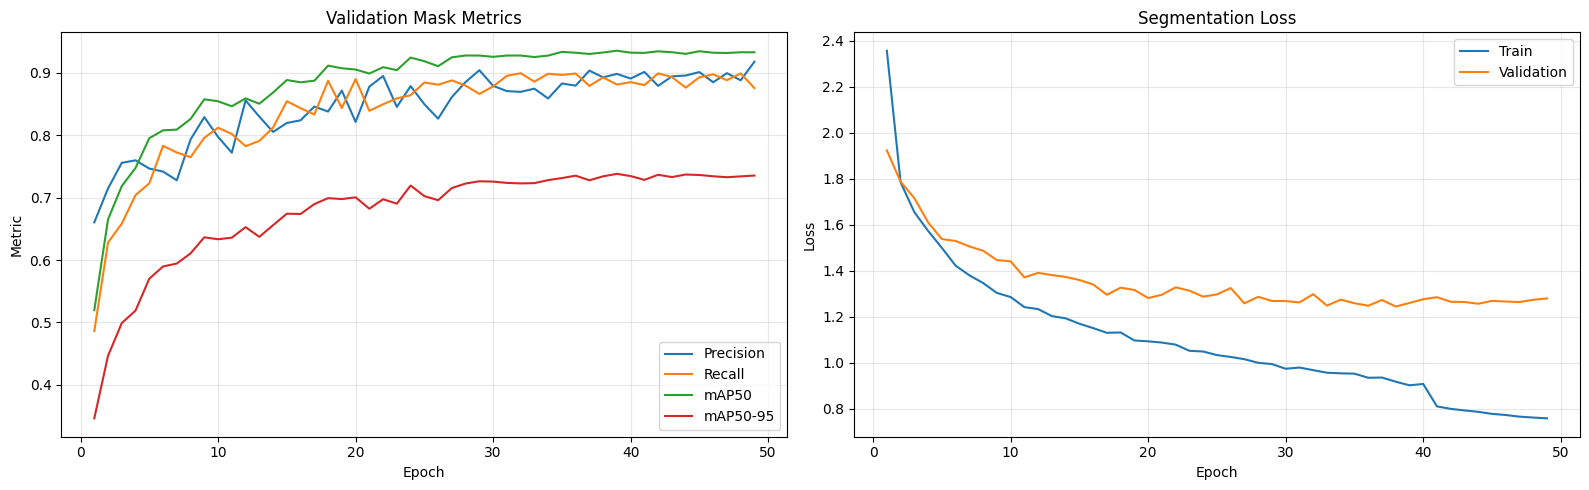

Curves saved: /kaggle/working/qaddir-training-results/carparts_yolo11n_wheel_fixed_v3/training_curves_summary.png


In [19]:
results_csv = (
    RUNS_DIR
    / "carparts_yolo11n_wheel_fixed_v3"
    / "results.csv"
)

history = pd.read_csv(results_csv)
history.columns = history.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(
    history["epoch"],
    history["metrics/precision(M)"],
    label="Precision"
)
axes[0].plot(
    history["epoch"],
    history["metrics/recall(M)"],
    label="Recall"
)
axes[0].plot(
    history["epoch"],
    history["metrics/mAP50(M)"],
    label="mAP50"
)
axes[0].plot(
    history["epoch"],
    history["metrics/mAP50-95(M)"],
    label="mAP50-95"
)

axes[0].set_title("Validation Mask Metrics")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Metric")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    history["epoch"],
    history["train/seg_loss"],
    label="Train"
)
axes[1].plot(
    history["epoch"],
    history["val/seg_loss"],
    label="Validation"
)

axes[1].set_title("Segmentation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

CURVES_PATH = (
    RUNS_DIR
    / "carparts_yolo11n_wheel_fixed_v3"
    / "training_curves_summary.png"
)

plt.savefig(CURVES_PATH, dpi=150, bbox_inches="tight")
plt.show()

print("Curves saved:", CURVES_PATH)

### 7.3 Training Findings

The model converged steadily, with the validation mask metrics beginning to plateau after approximately 30 epochs. Validation segmentation loss remained stable without a sustained increase, indicating no severe overfitting.

The decrease in training loss around epoch 40 corresponds to disabling mosaic augmentation during the final 10 epochs. Overall, 50 epochs were sufficient for the corrected baseline, and further improvements should be explored through controlled hyperparameter tuning rather than simply extending training.

### 7.4 Qualitative Evaluation

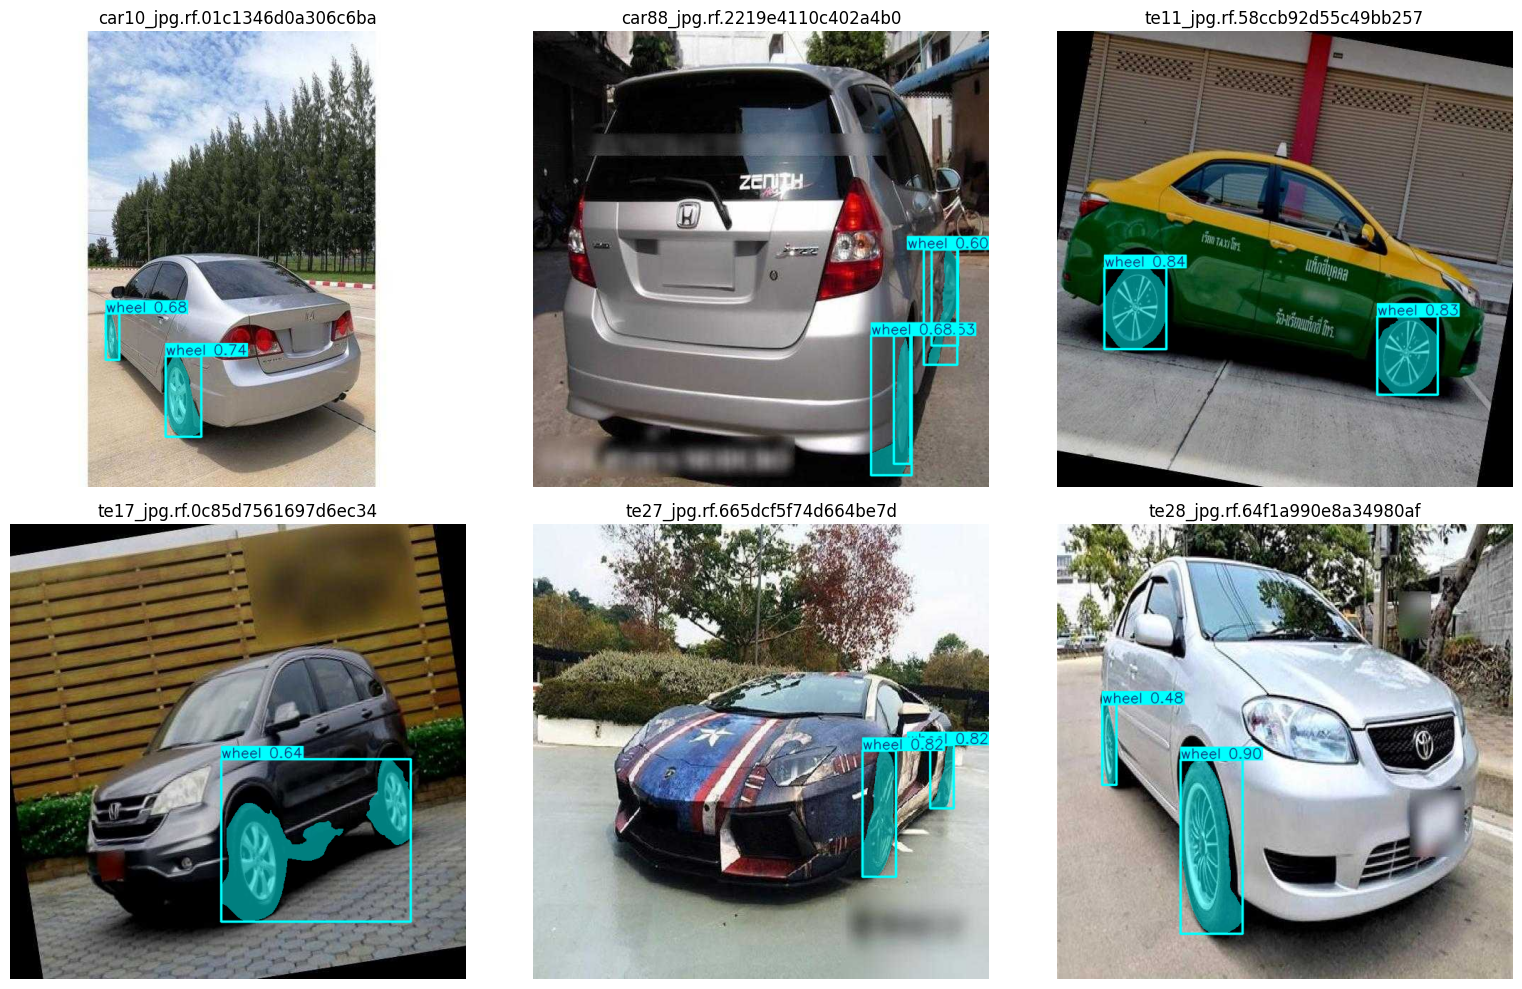

In [20]:
wheel_images = []
seen_sources = set()

for label_path in sorted(
    (DATASET_DIR / "labels" / "val").glob("*.txt")
):
    lines = label_path.read_text().splitlines()

    if not any(
        int(line.split()[0]) == 12
        for line in lines
        if line.strip()
    ):
        continue

    source_name = label_path.stem.split(".rf.")[0]

    if source_name in seen_sources:
        continue

    image_path = next(
        (DATASET_DIR / "images" / "val").glob(
            f"{label_path.stem}.*"
        )
    )

    seen_sources.add(source_name)
    wheel_images.append(image_path)

    if len(wheel_images) == 6:
        break

predictions = best_model.predict(
    source=[str(path) for path in wheel_images],
    classes=[12],
    conf=0.25,
    imgsz=640,
    device=0,
    retina_masks=True,
    verbose=False
)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for axis, prediction, image_path in zip(
    axes.flat,
    predictions,
    wheel_images
):
    axis.imshow(prediction.plot()[:, :, ::-1])
    axis.set_title(image_path.stem[:30])
    axis.axis("off")

plt.tight_layout()
plt.show()

In [21]:
problem_labels = list(
    (DATASET_DIR / "labels" / "val").glob("te17_jpg*.txt")
)

for label_path in problem_labels:
    wheel_instances = sum(
        int(line.split()[0]) == 12
        for line in label_path.read_text().splitlines()
        if line.strip()
    )

    print(label_path.name)
    print("Ground-truth wheel instances:", wheel_instances)

te17_jpg.rf.8a2f581c10643b30aa60228648efaa43.txt
Ground-truth wheel instances: 0
te17_jpg.rf.f445c20cde93223215ce626eb96cad0d.txt
Ground-truth wheel instances: 0
te17_jpg.rf.5da7fcf4d013a17bc39bc3eed33e570e.txt
Ground-truth wheel instances: 0
te17_jpg.rf.28e17d1fb888bc0ae8439f60022a3a25.txt
Ground-truth wheel instances: 0
te17_jpg.rf.0c85d7561697d6ec34902d29915955d9.txt
Ground-truth wheel instances: 2
te17_jpg.rf.24f9f828bac5b8de775051f36a1bead5.txt
Ground-truth wheel instances: 2
te17_jpg.rf.22fb62cb25aa4ef280ae374dbb187176.txt
Ground-truth wheel instances: 0


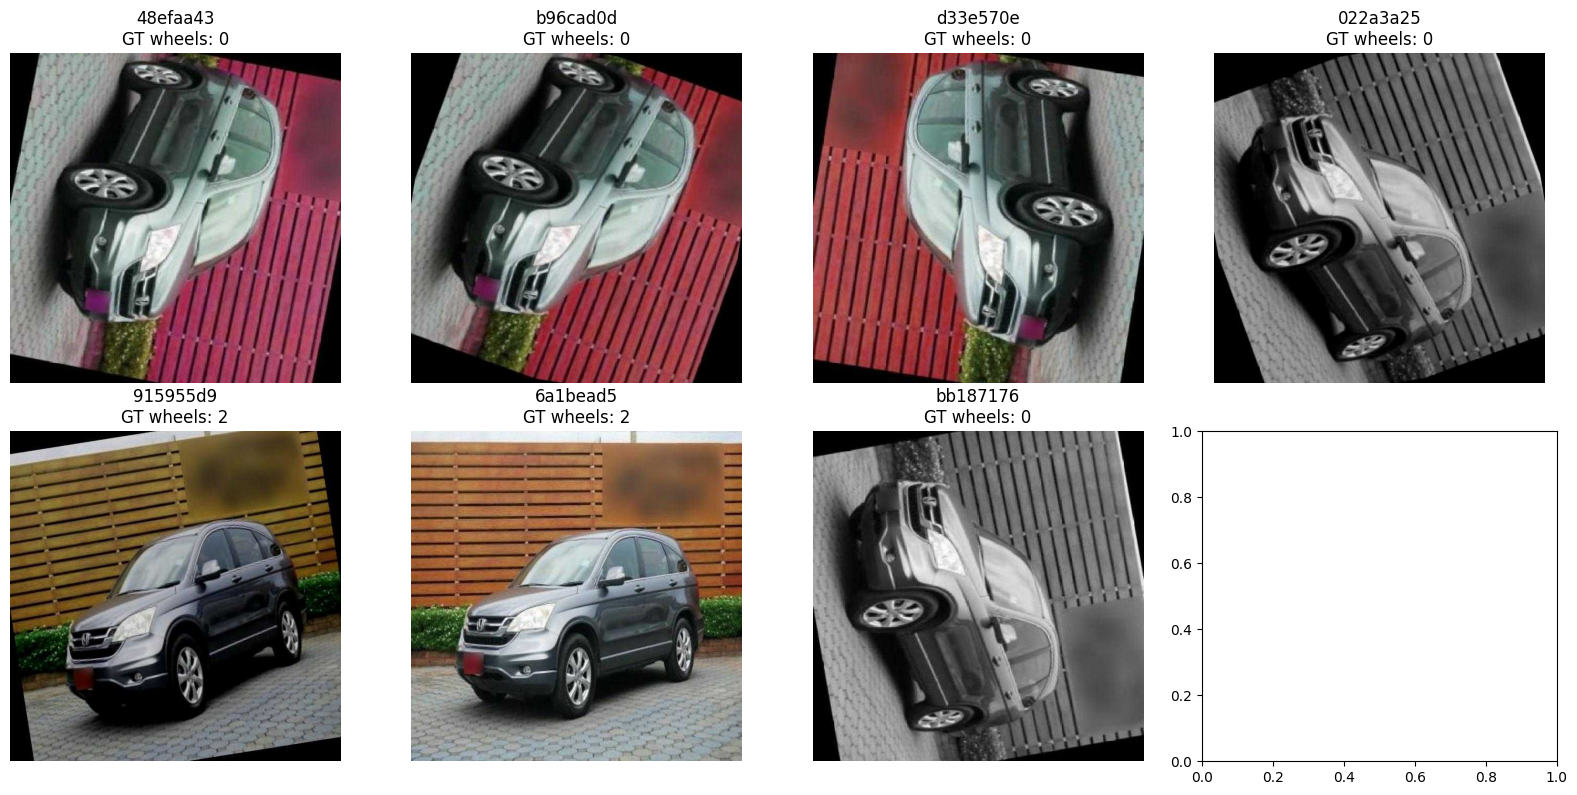

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flat

for axis, label_path in zip(axes, problem_labels):
    image_path = next(
        (DATASET_DIR / "images" / "val").glob(
            f"{label_path.stem}.*"
        )
    )

    wheel_instances = sum(
        int(line.split()[0]) == 12
        for line in label_path.read_text().splitlines()
        if line.strip()
    )

    axis.imshow(Image.open(image_path))
    axis.set_title(
        f"{label_path.stem[-8:]}\n"
        f"GT wheels: {wheel_instances}"
    )
    axis.axis("off")

for axis in list(axes)[len(problem_labels):]:
    axis.axis("off")

plt.tight_layout()
plt.show()

## 8. Decisions and Next Steps

### 8.1 Current Dataset Summary

| Split | Images | Wheel polygons |
|---|---:|---:|
| Train | 3,269 | 2,005 |
| Validation | 561 | 188 |
| Test | 554 | 176 |

### 8.2 Current Validation Results

| Metric | Result |
|---|---:|
| Overall Mask mAP50-95 | 0.737 |
| Wheel Mask Precision | 0.833 |
| Wheel Mask Recall | 0.761 |
| Wheel Mask mAP50 | 0.878 |
| Wheel Mask mAP50-95 | 0.618 |

These values describe the current wheel-fixed baseline. The validation tables and training curves above are retained as the supporting evidence.

### 8.3 Missing Wheel Annotation Audit

Qualitative evaluation found augmented versions of some source images with visible wheels but no corresponding wheel annotation. The current audit scope is:

| Split | Candidate images | Source groups |
|---|---:|---:|
| Train | 1,212 | 249 |
| Validation | 262 | 54 |
| Test | 252 | 51 |

These are **audit candidates, not confirmed annotation errors**. Each case must be reviewed and classified as `correct`, `exclude`, or `retain`. Decisions should remain consistent at the source-group level while accounting for the geometry of each augmented image.

### 8.4 Next Steps

1. Complete the missing-wheel annotation review, prioritizing validation and test candidates.
2. Correct, exclude, or retain each candidate with an explicit reason.
3. Freeze the reviewed validation and test labels.
4. Begin controlled hyperparameter tuning only after the audit is complete.
5. Keep the current model as the wheel-fixed baseline for future comparisons.